## K-Means clustring Implementation

1. K-means work on groups when given a blank group
2. Its Lazy method becuse  its can not understand new data 
3. prediction is slow
4. kmean ++ use to solve Random Initialization Trap
5. When 2 centroid in one place to get it creat random intialization

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import seaborn as sns
%matplotlib inline

In [2]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2) # center=3 groups 

In [3]:
X

array([[-4.58146619,  0.78512016],
       [-5.48648065,  2.27085486],
       [-8.1952944 ,  1.80078274],
       ...,
       [ 1.56765457, -8.64912418],
       [-5.0983459 ,  0.78548812],
       [-2.37066297,  7.67769401]], shape=(1000, 2))

In [4]:
y

array([2, 2, 2, 1, 0, 1, 1, 0, 0, 2, 1, 0, 2, 1, 2, 0, 1, 2, 0, 0, 1, 2,
       2, 0, 2, 0, 0, 2, 2, 2, 0, 2, 1, 2, 1, 0, 0, 0, 1, 0, 1, 2, 2, 2,
       1, 1, 1, 2, 2, 0, 0, 1, 0, 2, 2, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       2, 1, 2, 0, 2, 0, 2, 1, 1, 0, 1, 1, 2, 0, 1, 0, 1, 1, 2, 2, 2, 0,
       0, 0, 0, 1, 2, 1, 0, 0, 2, 2, 1, 1, 2, 2, 1, 2, 0, 2, 2, 2, 2, 0,
       0, 2, 1, 0, 0, 2, 2, 1, 0, 2, 2, 2, 0, 0, 2, 2, 1, 0, 1, 1, 2, 1,
       1, 0, 0, 2, 0, 1, 2, 2, 0, 2, 0, 2, 0, 2, 1, 1, 0, 1, 1, 2, 1, 0,
       0, 0, 0, 0, 2, 1, 1, 2, 0, 2, 1, 0, 0, 1, 2, 1, 0, 0, 0, 1, 2, 2,
       2, 0, 2, 0, 1, 1, 0, 1, 1, 2, 2, 1, 0, 2, 1, 2, 2, 0, 2, 0, 2, 2,
       1, 2, 0, 2, 2, 2, 1, 0, 2, 0, 0, 1, 2, 1, 0, 2, 1, 0, 2, 1, 1, 0,
       2, 1, 0, 0, 0, 2, 2, 0, 1, 0, 1, 1, 0, 2, 2, 1, 2, 1, 0, 1, 0, 1,
       2, 0, 0, 1, 2, 0, 2, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 0, 2, 1, 2, 0, 0, 1, 2, 1, 2, 1, 1, 0, 2, 1, 0, 0,
       2, 0, 2, 1, 0, 2, 0, 0, 2, 0, 1, 1, 2, 0, 1,

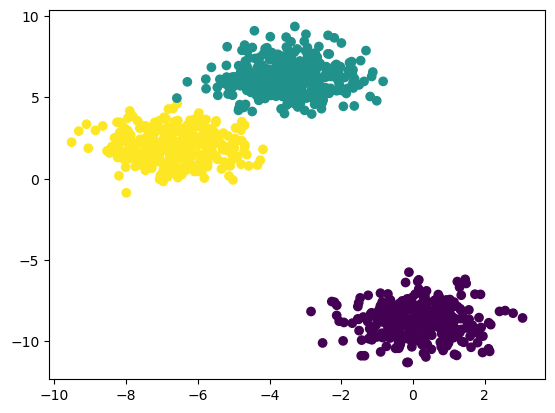

In [5]:
plt.scatter(X[:,0],X[:,1],c=y)

In [6]:
## Standerdization --Feature Scaling 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [7]:
## first i train the data 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.33,random_state=42)

In [8]:
X_train_scale= scaler.fit_transform(X_train)
X_test_Scale = scaler.transform(X_test)

In [9]:
X_train


array([[ -3.04320682,   6.03840377],
       [  0.47849001,  -9.23892987],
       [ -7.13651312,   1.7563853 ],
       ...,
       [  1.36231608, -10.00715611],
       [ -4.25688091,   1.13656305],
       [ -3.7789784 ,   7.19424362]], shape=(670, 2))

### Importing the kMean

In [10]:
from sklearn.cluster import KMeans

## Within-Cluster Sum of Squares(WCCS)
1. Low inertia = points are close to their center =  Good clustering
2. High inertia = points are scattered =  Poor clustering

In [11]:
##  Elbow method to select K_values
wccs = [] 
for k in range(1,11):
    k_means = KMeans(n_clusters=k,init='k-means++')
    k_means.fit(X_train_scale)
    wccs.append(k_means.inertia_) # inertia_ is Within-Cluster Sum of Squares(WCCS)

In [12]:
wccs

[1339.9999999999998,
 269.7531802835444,
 86.90742711295388,
 73.05855613877847,
 57.33563713862789,
 53.250719910954714,
 39.098570873133966,
 34.268537061915424,
 30.927653793168158,
 26.402649362433145]

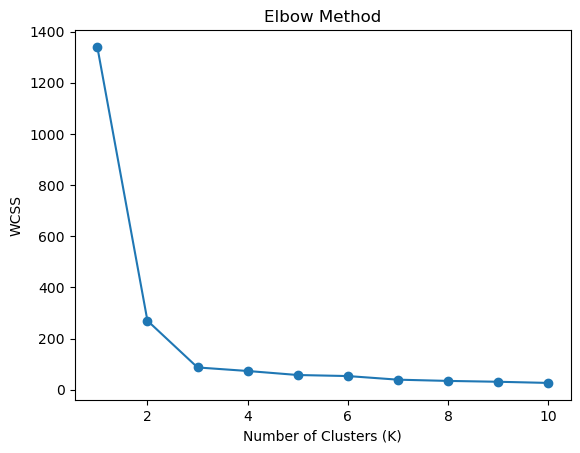

In [13]:
## Plot the elbow
import matplotlib.pyplot as plt

plt.plot(range(1, 11), wccs, marker='o')
# plt.xticks(range(1,11))
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [14]:
k_means = KMeans(n_clusters=3,init='k-means++')

In [15]:
k_means.fit_predict(X_train_scale)

array([0, 1, 2, 0, 2, 2, 2, 0, 0, 2, 1, 0, 1, 2, 0, 1, 0, 2, 1, 0, 0, 1,
       2, 1, 2, 0, 0, 0, 2, 1, 1, 1, 2, 0, 0, 2, 0, 1, 0, 2, 0, 0, 1, 0,
       0, 2, 2, 0, 1, 1, 1, 2, 1, 2, 2, 2, 1, 0, 0, 1, 2, 2, 1, 2, 1, 0,
       1, 0, 1, 1, 2, 1, 1, 2, 1, 1, 0, 2, 0, 0, 0, 2, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 2, 0, 2, 2, 0, 1, 1, 2, 1, 2, 0, 1, 2, 2, 1, 0, 2, 2,
       1, 1, 1, 0, 2, 1, 1, 2, 2, 2, 2, 0, 2, 2, 2, 0, 1, 1, 1, 1, 0, 1,
       2, 1, 2, 1, 1, 1, 0, 0, 0, 2, 0, 1, 0, 2, 0, 2, 1, 0, 0, 1, 1, 1,
       0, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 1, 1, 2, 1, 1, 1, 1, 1,
       1, 0, 2, 2, 1, 2, 2, 1, 0, 0, 1, 1, 2, 2, 1, 0, 0, 0, 1, 2, 2, 2,
       0, 0, 0, 2, 2, 1, 0, 1, 1, 1, 1, 0, 1, 0, 2, 2, 0, 2, 0, 1, 2, 0,
       2, 2, 1, 2, 2, 2, 2, 0, 0, 2, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 2,
       2, 1, 1, 1, 1, 1, 1, 2, 0, 1, 2, 1, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0,
       0, 1, 1, 2, 2, 2, 2, 1, 1, 1, 0, 0, 0, 2, 0, 1, 0, 1, 2, 2, 2, 2,
       0, 1, 0, 0, 2, 1, 1, 1, 0, 2, 2, 0, 1, 2, 1,

In [16]:
y_pred = k_means.predict(X_test_Scale)

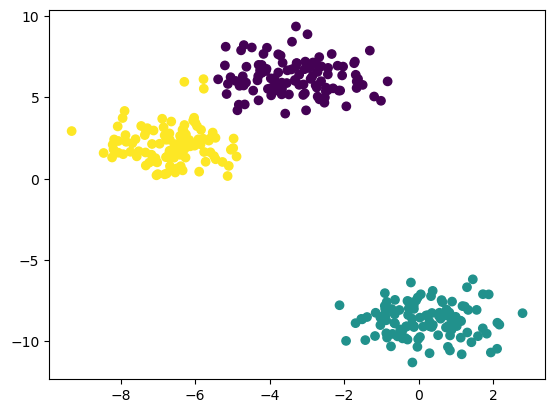

In [17]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [18]:
## Validating the k value 
## Kneelocater
## Silhoid scoring

In [19]:
## Kneelocater 
from kneed import KneeLocator


In [20]:
k1 = KneeLocator(range(1,11), wccs, curve='convex', direction='decreasing')

In [21]:
k1.elbow

np.int64(3)

In [22]:
## Silhotte score 
from sklearn.metrics import silhouette_score

In [23]:
silhouette_coffiecent = [] 
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scale)
    score= silhouette_score(X_train_scale,kmeans.labels_)
    silhouette_coffiecent.append(score)

In [24]:
silhouette_coffiecent

[0.7347675439541219,
 0.7077598531244127,
 0.5943739740227739,
 0.46303114152035557,
 0.4013728086877136,
 0.39042055333284736,
 0.38641726266547577,
 0.38126826145815274,
 0.36478433836189994]

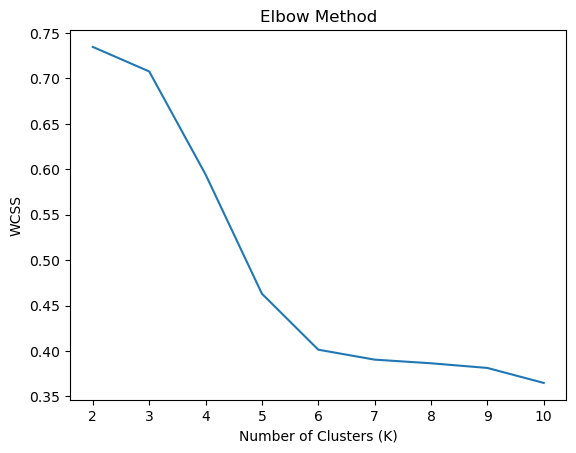

In [27]:
## Ploting the silhotte score
plt.plot(range(2,11),silhouette_coffiecent)
# plt.xticks(range(2,11))
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()